In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# create date range 
date = pd.date_range(start='2022-01-01',periods=200)

#create prduction data

production = np.random.randint(80, 120,size=200)

df = pd.DataFrame({
    'Date': date,
    'Production': production
})

df.set_index('Date',inplace=True)

df.head()

,production
Date,
2022-01-01,102
2022-01-02,99
2022-01-03,82
2022-01-04,114
2022-01-05,81


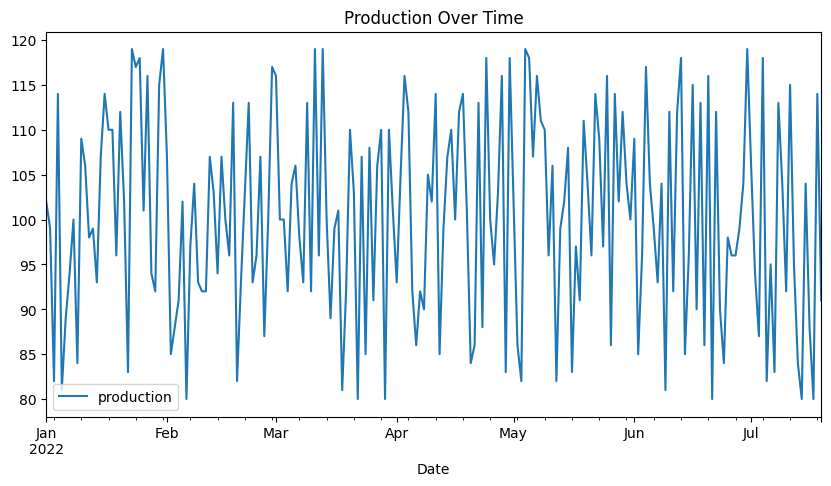

In [2]:
df.plot(figsize=(10,5))
plt.title("Production Over Time")
plt.show()

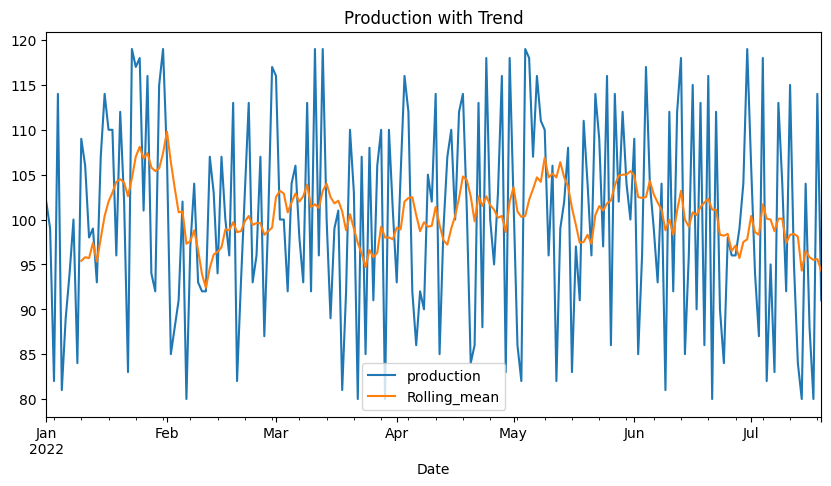

In [5]:
df['Rolling_mean'] = df['production'].rolling(window=10).mean()

df.plot(figsize=(10,5))
plt.title("Production with Trend")
plt.show()

In [7]:
df['Forecast'] = df['production'].rolling(window=10).mean()

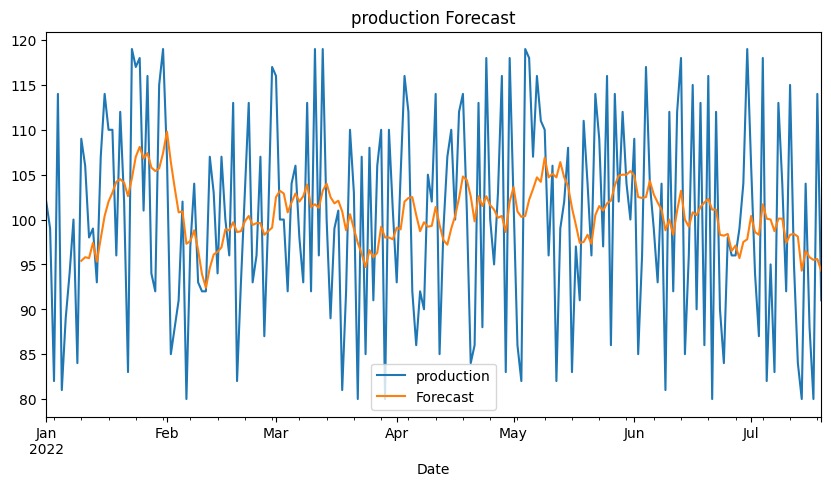

In [10]:
df[['production', 'Forecast']].plot(figsize=(10,5))
plt.title("production Forecast")
plt.show()

In [11]:
future_forecast = df['production'].tail(10).mean()
print("Next day predicted production:", future_forecast)

Next day predicted production: 94.3


In [12]:
pip install statsmodels

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [13]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(df['production'], order=(1,1,1))
model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:             production   No. Observations:                  200
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -766.026
Date:                Sun, 19 Apr 2026   AIC                           1538.052
Time:                        10:40:16   BIC                           1547.932
Sample:                    01-01-2022   HQIC                          1542.050
                         - 07-19-2022                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1215      0.073     -1.672      0.094      -0.264       0.021
ma.L1         -0.9998      1.096     -0.912      0.362      -3.147       1.148
sigma2       125.6181    137.563      0.913      0.3

C:\Users\pabha\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\pabha\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\pabha\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [14]:
forecast = model_fit.forecast(steps=10)
print(forecast)

2022-07-20    101.451171
2022-07-21    100.181238
2022-07-22    100.335549
2022-07-23    100.316799
2022-07-24    100.319077
2022-07-25    100.318800
2022-07-26    100.318834
2022-07-27    100.318830
2022-07-28    100.318830
2022-07-29    100.318830
Freq: D, Name: predicted_mean, dtype: float64
